In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
import numpy as np
import xarray as xr

In [2]:
var='w'

Ug = 0.075
# vmax=0.00075
vmax = 0.01
vmin=-vmax
colormap='viridis'
colormap='bwr'
colormap='RdBu_r'

hgts_c=[ 2.12]#, 10.03]
hgts_h=[ 2.26]#, 9.88]

hgts_c=[ 10.03]
hgts_h=[ 9.88]

fs=14

In [3]:
path_dns='/glade/u/home/adac/work/DNSdata/DNS_SBL_L320/Re2700/'

timesteps=[1386000]
nt=len(timesteps)

ds = xr.open_dataset(path_dns+var+str(timesteps[0])+'.nc',decode_times=0)
print(ds)

try:
  x=ds['xh'].values
except:
  x=ds['x'].values
nx=len(x)

try:
  y=ds['yh'].values
except:
  y=ds['y'].values
ny=len(y)

try:
  z=ds['zh'].values
  hgts=hgts_h
except:
  z=ds['z'].values
  hgts=hgts_c

<xarray.Dataset> Size: 18GB
Dimensions:  (x: 960, y: 960, zh: 4992, time: 1)
Coordinates:
  * x        (x) float32 4kB 0.01426 0.04279 0.07132 ... 27.31 27.34 27.37
  * y        (y) float32 4kB 0.01426 0.04279 0.07132 ... 27.31 27.34 27.37
  * zh       (zh) float32 20kB 0.0 0.003621 0.007242 ... 18.06 18.07 18.07
  * time     (time) int32 4B -2147483647
Data variables:
    w        (time, zh, y, x) float32 18GB ...


<xarray.Dataset> Size: 18GB
Dimensions:  (x: 960, y: 960, zh: 4992, time: 1)
Coordinates:
  * x        (x) float32 4kB 0.01426 0.04279 0.07132 ... 27.31 27.34 27.37
  * y        (y) float32 4kB 0.01426 0.04279 0.07132 ... 27.31 27.34 27.37
  * zh       (zh) float32 20kB 0.0 0.003621 0.007242 ... 18.06 18.07 18.07
  * time     (time) int32 4B -2147483647
Data variables:
    w        (time, zh, y, x) float32 18GB ...


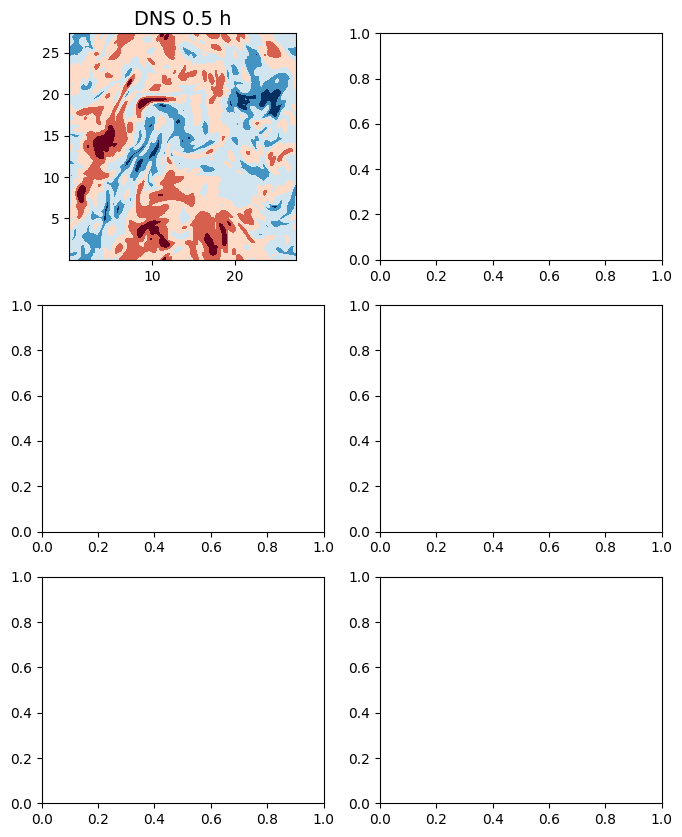

In [4]:
for hgt in hgts:
    k = np.abs(z - hgt).argmin()
    for it, timestep in enumerate(timesteps):
        fig, ax = plt.subplots(3,2,figsize = (8, 10))

        ds = xr.open_dataset(path_dns+var+str(timestep)+'.nc',decode_times=0)
        print(ds)

        w=ds[var][0,k].values

        ax[0,0].contourf(x,y,w/Ug,vmin=vmin,vmax=vmax,cmap=colormap)
        ax[0,0].set_aspect('equal')
        ax[0,0].set_title('DNS 0.5 h',fontsize=fs)

<xarray.Dataset> Size: 17MB
Dimensions:  (z: 64, y: 32, x: 32, time: 3)
Coordinates:
  * z        (z) float64 512B 0.5648 0.8473 1.13 1.412 ... 17.79 18.07 18.36
  * y        (y) float64 256B 0.4279 1.284 2.14 2.995 ... 24.39 25.25 26.1 26.96
  * x        (x) float64 256B 0.4279 1.284 2.14 2.995 ... 24.39 25.25 26.1 26.96
  * time     (time) int64 24B 1368000 1377000 1386000
Data variables:
    u        (z, y, x, time) float64 2MB ...
    v        (z, y, x, time) float64 2MB ...
    w        (z, y, x, time) float64 2MB ...
    tau11    (z, y, x, time) float64 2MB ...
    tau22    (z, y, x, time) float64 2MB ...
    tau33    (z, y, x, time) float64 2MB ...
    tau12    (z, y, x, time) float64 2MB ...
    tau13    (z, y, x, time) float64 2MB ...
    tau23    (z, y, x, time) float64 2MB ...
    b        (z, y, x, time) float64 2MB ...
    p        (z, y, x, time) float64 2MB ...


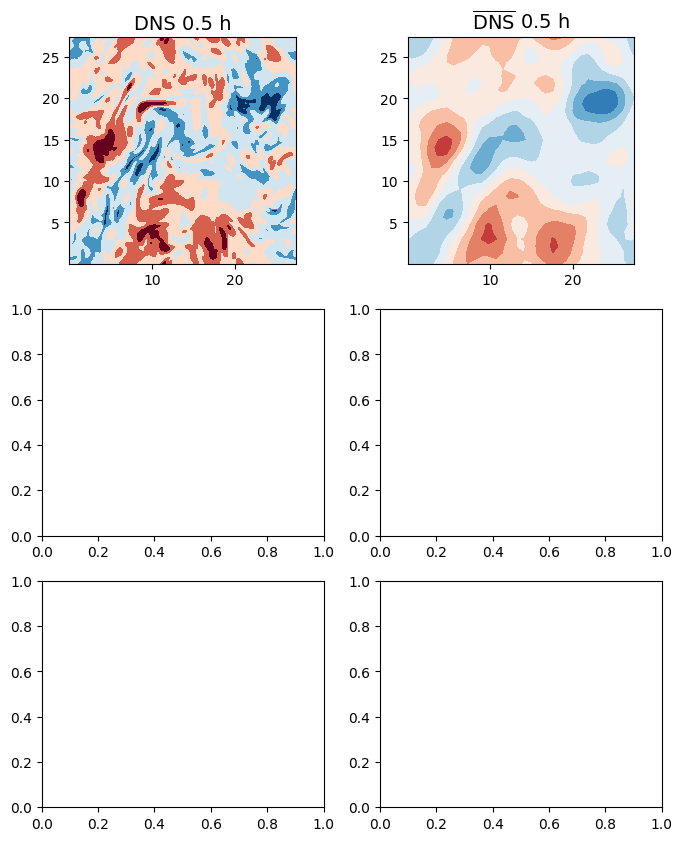

In [5]:
path_les="/glade/work/adac/DNStoLES/coarseData/"
file="coarse4x3078_Re2700.nc"
title=r'$\overline{\text{DNS}}$ 0.5 h'
dscoarse = xr.open_dataset(path_les+file)
print(dscoarse)

zcoarse=dscoarse['z'].values
#yc=dscoarse['y'].values
xc=dscoarse['x'].values
dx=np.mean(np.diff(xc))

xcoarse=np.concatenate(([xc[0]-dx/2.0],xc,[xc[-1]+dx/2.0]))
ycoarse=xcoarse
#print(xcoarse[0])
#print(xcoarse[-1])

dacoarse=dscoarse[var]


for hgt in hgts:
    kcoarse = np.abs(zcoarse - hgt).argmin()
    for it, timestep in enumerate(timesteps):

        ucoarse=dacoarse.sel(time=timestep)[kcoarse].values
        ucoarse=np.insert(ucoarse,0,(ucoarse[:,-1]+ucoarse[:,0])/2.0,axis=1)
        ucoarse=np.column_stack((ucoarse,ucoarse[:,0]))#,axis=1)
        ucoarse=np.insert(ucoarse,0,(ucoarse[-1,:]+ucoarse[0,:])/2.0,axis=0)
        ucoarse=np.row_stack((ucoarse,ucoarse[0,:]))#,axis=0)

        ax[0,1].contourf(xcoarse,ycoarse,ucoarse/Ug,vmin=vmin,vmax=vmax,cmap=colormap)
        ax[0,1].set_aspect('equal')
        ax[0,1].set_title(title,fontsize=fs)
        
fig

In [6]:
path='../cases/SBL_DNN_run/'
ds = xr.open_dataset(path+var+'.nc')
print(ds)

try:
  x=ds['xh'].values
except:
  x=ds['x'].values

try:
  y=ds['yh'].values
except:
  y=ds['y'].values

try:
  z=ds['zh'].values
  hgts=hgts_h
except:
  z=ds['z'].values
  hgts=hgts_c

timeLabels=['C4DNN 0.5 h','C4DNN 6.0 h']
timesteps=[1,12]

for iLES, timestep in enumerate(timesteps):
    for hgt in hgts:
        k = np.abs(z - hgt).argmin()
        
        w=ds[var][timestep].values
        
        ax[1,iLES].contourf(x,y,w[k]/Ug,vmin=vmin,vmax=vmax,cmap=colormap)

        ax[1,iLES].set_aspect('equal')
        ax[1,iLES].set_title(timeLabels[iLES],fontsize=fs)

<xarray.Dataset> Size: 7MB
Dimensions:  (time: 13, y: 32, x: 32, zh: 64)
Coordinates:
  * time     (time) float64 104B 0.0 1.8e+03 3.6e+03 ... 1.98e+04 2.16e+04
  * y        (y) float64 256B 0.4279 1.284 2.14 2.995 ... 24.39 25.25 26.1 26.96
  * x        (x) float64 256B 0.4279 1.284 2.14 2.995 ... 24.39 25.25 26.1 26.96
  * zh       (zh) float64 512B 0.0 0.2824 0.5648 0.8473 ... 17.23 17.51 17.79
Data variables:
    w        (time, zh, y, x) float64 7MB ...


In [7]:
path='../cases/SBL_Smag_run/'
ds = xr.open_dataset(path+var+'.nc')
print(ds)

try:
  x=ds['xh'].values
except:
  x=ds['x'].values

try:
  y=ds['yh'].values
except:
  y=ds['y'].values

try:
  z=ds['zh'].values
  hgts=hgts_h
except:
  z=ds['z'].values
  hgts=hgts_c

timeLabels=['Smagorinsky 0.5 h','Smagorinsky 6.0 h']
timesteps=[1,12]

for iLES, timestep in enumerate(timesteps):
    for hgt in hgts:
        k = np.abs(z - hgt).argmin()
        
        w=ds[var][timestep].values
        
        ax[2,iLES].contourf(x,y,w[k]/Ug,vmin=vmin,vmax=vmax,cmap=colormap)

        ax[2,iLES].set_aspect('equal')
        ax[2,iLES].set_title(timeLabels[iLES],fontsize=fs)

<xarray.Dataset> Size: 7MB
Dimensions:  (time: 13, y: 32, x: 32, zh: 64)
Coordinates:
  * time     (time) float64 104B 0.0 1.8e+03 3.6e+03 ... 1.98e+04 2.16e+04
  * y        (y) float64 256B 0.4279 1.284 2.14 2.995 ... 24.39 25.25 26.1 26.96
  * x        (x) float64 256B 0.4279 1.284 2.14 2.995 ... 24.39 25.25 26.1 26.96
  * zh       (zh) float64 512B 0.0 0.2824 0.5648 0.8473 ... 17.23 17.51 17.79
Data variables:
    w        (time, zh, y, x) float64 7MB ...


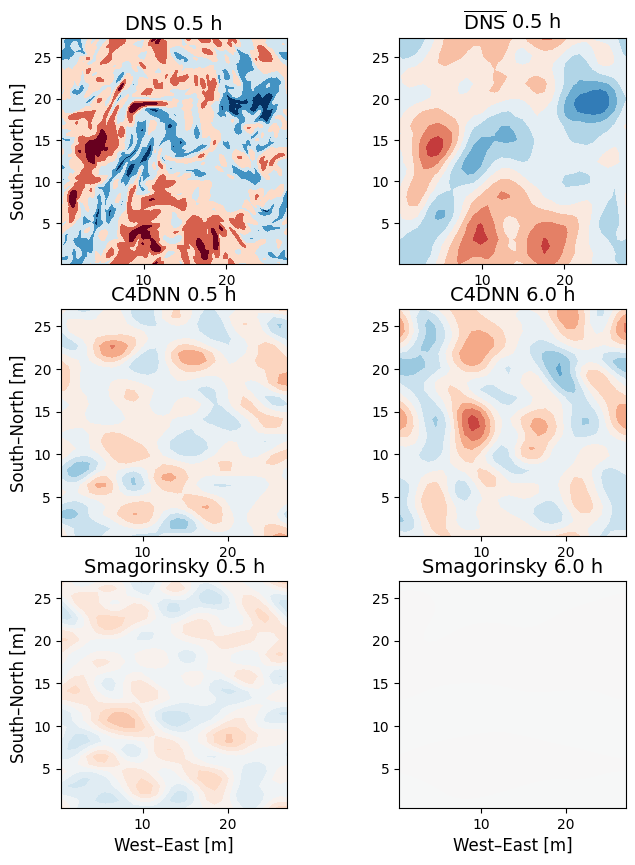

In [8]:
for j in range(len(ax[0])):
    for i in range(len(ax)):
        ax[i,0].set_ylabel('South–North [m]',fontsize=12)
        ax[2,j].set_xlabel('West–East [m]',fontsize=12)
        ax[i,j].tick_params(labelsize=10)
       
fig

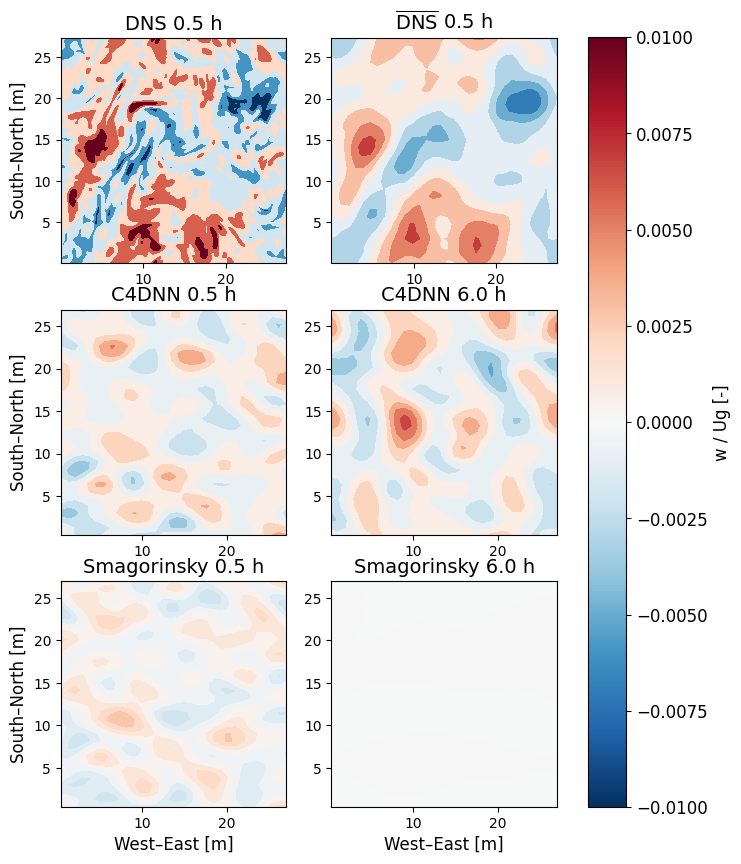

In [9]:
# fig.subplots_adjust(right=0.8)
cb=fig.colorbar(cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=vmin,vmax=vmax), cmap=colormap),ax=ax.ravel().tolist())
cb.ax.tick_params(labelsize=12)
# cb.set_label(label='Vertical Velocity [m s$^{-1}$]',fontsize=12)
cb.set_label(label='w / Ug [-]',fontsize=12)
# plt.tight_layout()      
fig

In [10]:
save=True
if save:
    plt.figure(fig)
    fmts=["png","eps"]
    for fmt in fmts:
        plt.savefig("XYcontour_w."+fmt, format=fmt, bbox_inches="tight", pad_inches=0.01)